## Feature Engineering


##### Feature Engineering is the art of transforming raw, messy data columns into brand-new, highly informative columns that make it incredibly easy for a machine learning algorithm to learn.

## Correlation

##### Correlation measures the strength and direction of a linear relationship between two variables. It is represented by a score between -1.0 and +1.0.

##### Positive Correlation (+1.0): As the feature goes up, the output goes up. (e.g., As House Size increases, House Price increases).

##### Negative Correlation (-1.0): As the feature goes up, the output goes down. (e.g., As Car Mileage increases, Car Price decreases).

##### Zero Correlation (0.0): No linear relationship at all. (e.g., Your Lucky Number has zero correlation with Your Annual Income).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
np.random.seed(42)
data = {
    'Rooms': np.random.randint(1, 5, size=100),
    'Square_Feet': np.random.randint(500, 3500, size=100),
    'Age_of_House': np.random.randint(1, 50, size=100),
}
df = pd.DataFrame(data)

In [3]:
df['Price'] = (df['Square_Feet'] * 150) + (df['Rooms'] * 10000) - (df['Age_of_House'] * 500) + np.random.normal(0, 5000, size=100)

In [4]:
# Feature Engineering

df['Avg_Room_Size'] = df['Square_Feet'] / df['Rooms']

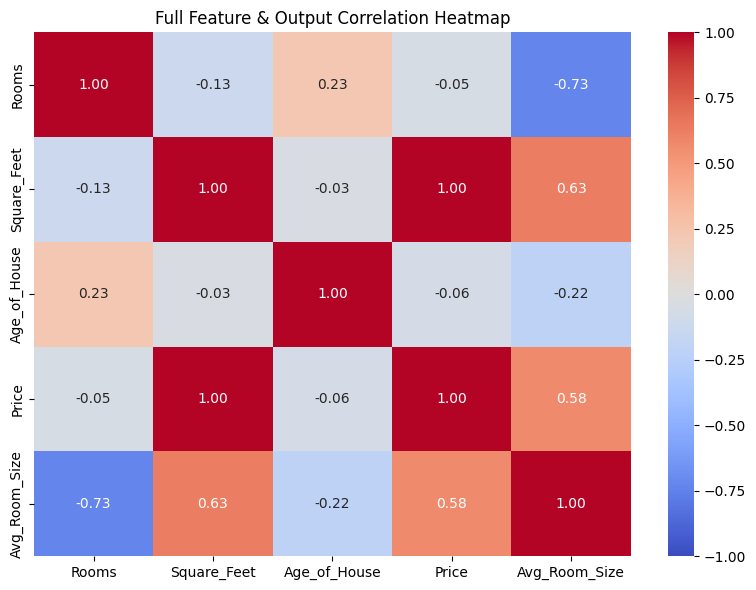

In [9]:
# Implementing correlation matrix

corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1
)

plt.title("Full Feature & Output Correlation Heatmap")
plt.tight_layout()
plt.show()

### Working behind


##### When you run df.corr(), Pandas uses Pearson Correlation by default. Pearson only measures straight-line linear relationships. If your data has a complex, curved mathematical pattern, Pearson will completely miss it and mistakenly claim the correlation is close to 0.


### For Non-Linear correlation

##### If a feature rises exponentially or in a wave format alongside your output, you must switch your mathematical approach:

- **Spearman Rank Correlation: Measures monotonic relationships (whether variables move in the same direction, even if it's not a straight line).**
- **Kendall's Tau: Excellent for small datasets with many tied ranks or discrete ordinal scales.**
- **spearman_corr = df.corr(method='spearman')**

### Predictive Power Score(PPS)

##### Modern data scientists use the Predictive Power Score (PPS) framework. It trains an isolated, non-linear Decision Tree model behind the scenes for every single column pair to calculate a score from 0 to 1, completely unearthing hidden multi-column patterns that a standard heatmap leaves invisible.
